# Does this agree with the people who were there?

*Question, Intuition, Math, Code, Assumptions, How it breaks*

## 1. Question

Every check in this book so far has been internal. The gate is consistent with
the requirement list, the requirement list with the definition, the intervals
with the data. All of that could be internally perfect while measuring entirely
the wrong thing.

So: does this ranking agree with the people who watched the football and voted
at the time? And where it disagrees, can it say why?

## 2. Intuition

Ballon d'Or voting is the one outside opinion available to me, and it needs no
new scraping because it is already sitting in Wikidata.

It is **not ground truth**, and I want to resist that temptation in both
directions. It rewards trophies won by teammates. It gets swayed by World Cups
this project cannot see. It leans toward forwards, and toward whoever won the
Champions League that year. A ranking that reproduced it perfectly would have
reproduced all of those biases too.

Which is exactly why it is worth comparing against rather than fitting to.
Agreement is evidence the method measures something real. **Disagreement is the
more interesting output**, because every disagreement has a nameable cause, and
a method that cannot name it is not defensible.

## 3. Math

There is deliberately no single statistic here.

The obvious move would be a rank correlation, Spearman's $\rho$ between award
count and my rank. It would be a mistake. Only eighteen players won anything in
the window, so $\rho$ would be computed on a tiny and extremely selected subset,
and it would compress the one thing worth seeing down into a single number.

So, three counts instead, kept apart on purpose:

1. winners **present** in my data at all,
2. winners who **clear the gate**,
3. winners the gate **rejects**, with the requirement responsible.

Keeping (1) separate from (3) matters. "We never saw this player" is a data
failure and "we ranked this player badly" is a method disagreement, and adding
them together would hide whichever one is mine.

In [1]:
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (10, 5.5)

SAMPLE = "../data/sample"
ranking = pd.read_parquet(f"{SAMPLE}/ranking.parquet")
winners = pd.read_csv(f"{SAMPLE}/award_winners.csv")
agreement = pd.read_csv(f"{SAMPLE}/awards_agreement.csv")

In [2]:
agreement.style.hide(axis="index")

measure,value
award winners in the window,18
"of those, present in our data",16
"of those, clearing all requirements",10
median rank of a winner,60
winners inside our top 55,8
winners our gate rejects,6


Ten of the sixteen located winners clear every requirement, and the median
winner ranks 60th out of 5,508, which is the top 1.1%. For a definition written
without reference to any award, that is substantial agreement.

Now for the part that is actually worth reading.

In [3]:
placed = winners[winners["rank"].notna()].copy()
placed["verdict"] = np.where(
    placed["qualified"].fillna(False).astype(bool),
    "qualified",
    "failed: " + placed["failed"].fillna("-"),
)
(
    placed.sort_values("rank")[["player", "honours", "award_years", "rank", "verdict"]].style.hide(
        axis="index"
    )
)

player,honours,award_years,rank,verdict
Lionel Messi,12,"2009, 2010, 2011, 2012, 2015, 2019, 2021, 2023",1.000000,qualified
Cristiano Ronaldo,7,"2008, 2013, 2014, 2016, 2017",2.000000,qualified
Mohamed Salah,1,2018,6.000000,qualified
Robert Lewandowski,1,2020,9.000000,qualified
Karim Benzema,1,2022,10.000000,qualified
Ronaldo,2,2002,13.000000,qualified
Andriy Shevchenko,1,2004,34.000000,qualified
Ronaldinho,3,"2004, 2005",40.000000,qualified
Kaká,2,2007,81.000000,qualified
Zinédine Zidane,2,"2000, 2003",92.000000,qualified


## 4. Where it disagrees, and why

Read the bottom of that table rather than the top.

**Cannavaro, 2,707th.** He won the 2006 Ballon d'Or as a centre-back and this
definition ranks him below two and a half thousand players, failing most of the
ten requirements. This is not a bug to be fixed. It is the
attacking-contribution limitation stated as a number instead of a caveat. FBref
records no per-player defensive action before 2017-18, so two thirds of the
window has nothing at all to measure a defender with. Van Dijk, 2019, fails on
creation for the same reason.

**Three winners fail on discipline alone.** Nedvěd, Figo and Rodri clear ten
requirements and get stopped by one. Whether that is right is a live question,
because my definition weights being booked the same as being unavailable, and
nobody has argued that those two deserve equal footing.

In [4]:
blame = (
    placed[~placed["qualified"].fillna(False).astype(bool)]["failed"]
    .str.split(", ")
    .explode()
    .value_counts()
)
print("requirements responsible for rejecting an award winner:\n")
print(blame.to_string())
print("\nDiscipline appears more than anything else, on players nobody would")
print("call undisciplined enough to disqualify. That is a finding about the")
print("definition, not about the players.")

requirements responsible for rejecting an award winner:

failed
discipline      4
creation        2
finishing       1
scoring         1
team_share      1
threat          1
availability    1
reliability     1

Discipline appears more than anything else, on players nobody would
call undisciplined enough to disqualify. That is a finding about the
definition, not about the players.


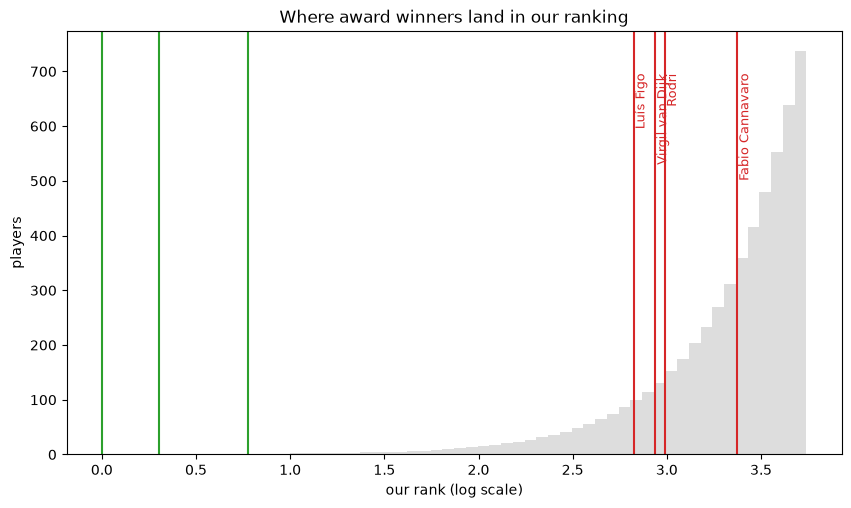

In [5]:
fig, ax = plt.subplots()
ax.hist(np.log10(ranking.index + 1), bins=60, color="#DDD", edgecolor="none")
for row in placed.nlargest(4, "rank").itertuples():
    ax.axvline(np.log10(row.rank), color="#D62728", linewidth=1.5)
    ax.text(
        np.log10(row.rank),
        ax.get_ylim()[1] * 0.9,
        f" {row.player}",
        rotation=90,
        va="top",
        fontsize=9,
        color="#D62728",
    )
for row in placed.nsmallest(3, "rank").itertuples():
    ax.axvline(np.log10(row.rank), color="#2CA02C", linewidth=1.5)
ax.set_xlabel("our rank (log scale)")
ax.set_ylabel("players")
ax.set_title("Where award winners land in our ranking")
plt.show()

## 5. Assumptions

1. **Award voting tracks playing quality.** Loosely, and with all the biases
   named above. It is a noisy second opinion, not a criterion.
2. **The window is comparable.** Awards are given for a calendar year and this
   project measures seasons, so a 2010 award spans two of mine. At this
   resolution the mismatch does not matter. For a season-by-season comparison it
   would.
3. **Identity resolution found them.** A winner I cannot match looks identical
   to a winner I ranked badly, which is exactly why the two get reported
   separately.

## 6. How it breaks

**This check found two bugs in itself before it found anything about football**,
which I would rather record than quietly fix.

The first run reported Cristiano Ronaldo, seven honours, as a player the data
had never seen. He was not missing from the ranking. He sits second. The
Wikidata fetch had silently lost the 1985 birth cohort, and 1985 is when both he
and Modrić were born.

The same run counted Birgit Prinz, Carli Lloyd and Aitana Bonmatí as winners I
had failed to find. Their absence is correct, because women's football is a
declared non-goal, but my query had not said so, and three correct absences were
being reported back to me as failures.

**The deeper limit: agreement here cannot validate the parts that matter most.**
Awards go overwhelmingly to forwards, so an attacking-contribution rating and a
forward-biased vote are going to agree for reasons that have nothing to do with
either of them being right. The agreement is real evidence, but it is evidence
about the population the two measures share. It is silent on defenders, which is
precisely where this project is weakest.